In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score #to check the number of cluster that may exist

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/archive/Instagram visits clustering.csv")

In [ ]:
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2600 non-null   int64  
 1   Instagram visit score    2600 non-null   int64  
 2   Spending_rank(0 to 100)  2600 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 61.1 KB


In [ ]:
df.describe() #the std here is normal. It is reasonable for the mean it is not too low

,User ID,Instagram visit score,Spending_rank(0 to 100)
count,2600.000000,2600.000000,2600.000000
mean,1299.500000,63.323462,42.848408
std,750.699674,26.579760,28.758349
min,0.000000,5.000000,0.940709
25%,649.750000,38.000000,19.452098
50%,1299.500000,72.000000,28.013082
75%,1949.250000,86.000000,72.116945
max,2599.000000,118.000000,107.349821


In [ ]:
df.isnull().sum()

,0
User ID,0
Instagram visit score,0
Spending_rank(0 to 100),0


In [ ]:
clustering_features = df[['Instagram visit score', 'Spending_rank(0 to 100)']] #we created a new data frame exclusing userID because userId is not useful for us, it is just ID. It will have no
#impact on our model. It is not a feature that helps find pattern. Clustering,here, would focus on visit score and spending patterns.
clustering_features.head()

,Instagram visit score,Spending_rank(0 to 100)
0,63,24.050708
1,61,25.223290
2,104,18.528245
3,82,86.890232
4,14,31.492397


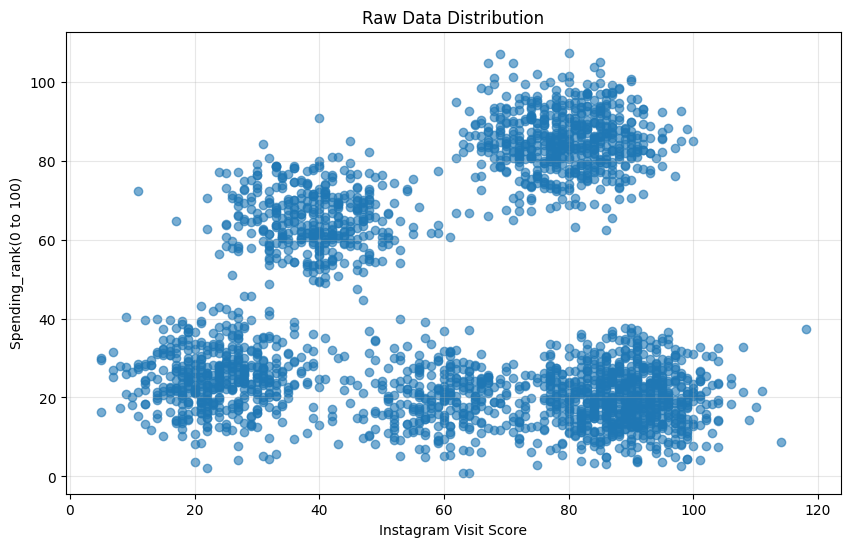

In [ ]:
#Visualize the raw data
plt.figure(figsize = (10,6))
plt.scatter(clustering_features['Instagram visit score'], clustering_features['Spending_rank(0 to 100)'], alpha = 0.6)
plt.xlabel('Instagram Visit Score')
plt.ylabel('Spending_rank(0 to 100)')
plt.title('Raw Data Distribution')
plt.grid(True, alpha = 0.3) #aplha = 0.3, here, makes the grid lines faint (semi-transparent)
plt.show()

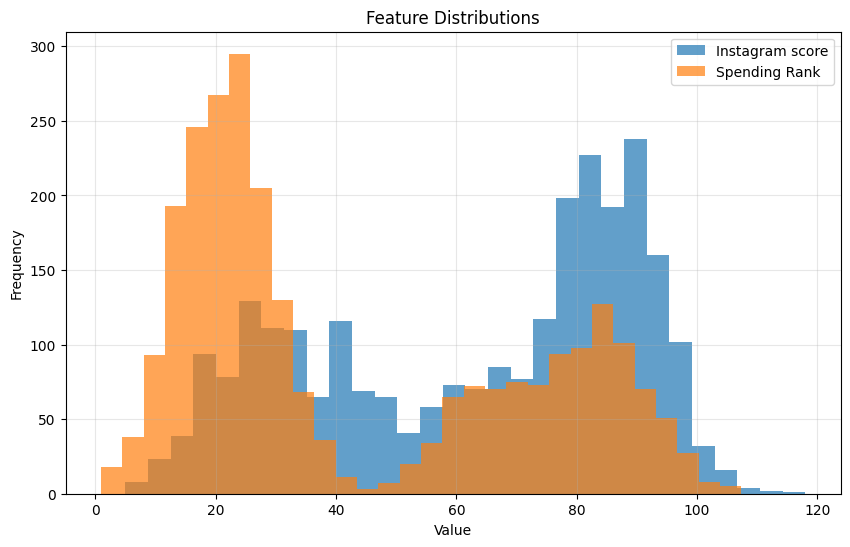

In [ ]:
plt.figure(figsize = (10,6))
plt.hist(clustering_features['Instagram visit score'], bins = 30, alpha = 0.7, label = 'Instagram score')
plt.hist(clustering_features['Spending_rank(0 to 100)'], bins = 30, alpha = 0.7, label = 'Spending Rank')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Feature Distributions')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

#here we plotted two histograms side by side; this is a bimodal distribution
# we did not include a color so python will give us two default colors

#Bimodal distribution
A bimodal is a type of data distribution that has two distinct peaks. Instagram visit is blue, spending rank is orange


#ELBOW METHOD
This will help us find the accurate number of clusters by checking how well the data fits into the different number of clusters

It runs the clustering algorithm (K-means) with different values of k (typically from 1 to 10 or more)

In [ ]:
# Test different numbers of clusters
k_range = range(2,11) #remember python doesn't add the last number so the last number in this range will actually be 10, not 11
empty_inertias = [] #empty_inertia is a variable here storing an empty list, we want to store our input in this empty list

for k in k_range:
  #Create KMeans model
  kmeans = KMeans(n_clusters = k, random_state=42, n_init=10) #n_clusters = number of clusters; n_init = 10 tries to fit each number from the range 10 times to find the characteristics of that number, you can do
  #n_init = any number, but we did 10 for better accuracy.

  #Fit the model
  kmeans.fit(clustering_features) #fitting in he Kmeans cluster algorithm

  #Store the inertia (within-cluster sum of squares)
  empty_inertias.append(kmeans.inertia_) #empty_inertia is our empty list, and inertia_ is a fxn that outputs all our inertia(inertia is the best value you get from the Kmeans clustering)
  #append we want to add the inertias into empty_inertia variable

  print(f"k={k}: Inertia = {kmeans.inertia_:.2f}")

  #The model checks if the number in the range fits the number of clusters, it will look for the charcteristics of that first number 10 times, basically it will try each number 10 times
  # for the unique charcterics bc we made n_init = 10, you ), if the number is not part of it, it will check the
  #next number

k=2: Inertia = 2079619.33
k=3: Inertia = 847024.58
k=4: Inertia = 440248.79
k=5: Inertia = 278407.52
k=6: Inertia = 251438.17
k=7: Inertia = 228195.72
k=8: Inertia = 208398.07
k=9: Inertia = 189725.80
k=10: Inertia = 174565.76


Look at the results, the Inertia became consistent after k=4. bc from k=5 to k=10, we can see that the Inertia don't ahve a big difference, it is somewhat going at a steady pace
unlike the difference in the inertias from k=1 to k=4. But since the consistency starts after k=4, then
#k=4 is the number clusters.

K_range = range(2,11): We are trying different values of k from 2 to 10
inertias = []: Empty list to store the WcSS (inertia) for each value of k
for k in k_range: Loop through each value of k(number of clusters)

n_init = 10: tries 10 diff starting points and picks the best

inertias.append: after fitting, get the inertia(within cluster sum of squares:the best cvalue you get from the Kmeans clustering) and save it in the empty list we created.

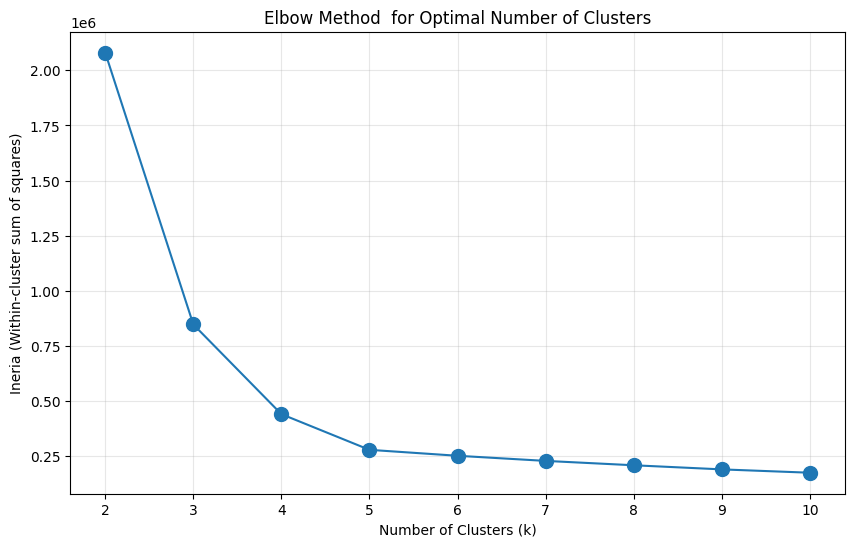

In [ ]:
#Plot the elbow curve
plt.figure(figsize=(10,6))
plt.plot(k_range, empty_inertias, 'o-', markersize = 10) #'0-': is the type of curve the graph is using; while markersize is size of the circle in this curve)
plt.title('Elbow Method  for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Ineria (Within-cluster sum of squares)')
plt.grid(True, alpha = 0.3)
plt.show()

#le6 on the top left of the graph is just python resizing our grpahs y label, that it is in thousands

Silhouette Score ranges from -1 to +1. It is often considered more reliable than the elbow method.

+1: perfect clustering(point is very close to its cluster, far from others)


0: Point is on the border between clusters


-1: Poor clustering (point might be in he wrong cluster)

Silhouettes scores predicts the number of clusters in the dataset

In [ ]:
silhouette_scores =[] #empty lsit stores all the scores we get from the model

for k in k_range:
  #Create and fit KMeans model
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  cluster_labels = kmeans.fit_predict(clustering_features) #fit the kmeans model to your features(clustering_features) and assigns each data point to a cluster
  #cluster_label is a list/array showing which cluster each point belongs to

  #Calculate silhouette score
  silhouette_avg = silhouette_score(clustering_features, cluster_labels) #computes the silhouette score for that clustering ranges from -1 to +1
  silhouette_scores.append(silhouette_avg)

  print(f"k={k}: Silhouette scores = {silhouette_avg: .3f}")

k=2: Silhouette scores =  0.490
k=3: Silhouette scores =  0.595
k=4: Silhouette scores =  0.647
k=5: Silhouette scores =  0.620
k=6: Silhouette scores =  0.539
k=7: Silhouette scores =  0.448
k=8: Silhouette scores =  0.446
k=9: Silhouette scores =  0.384
k=10: Silhouette scores =  0.339


#The answer is k =4 because the silhouette score for k = 4 is the highest amongst all the other scores

In [ ]:
print(cluster_labels[:10])

[0 0 0 2 3 2 2 2 1 0]


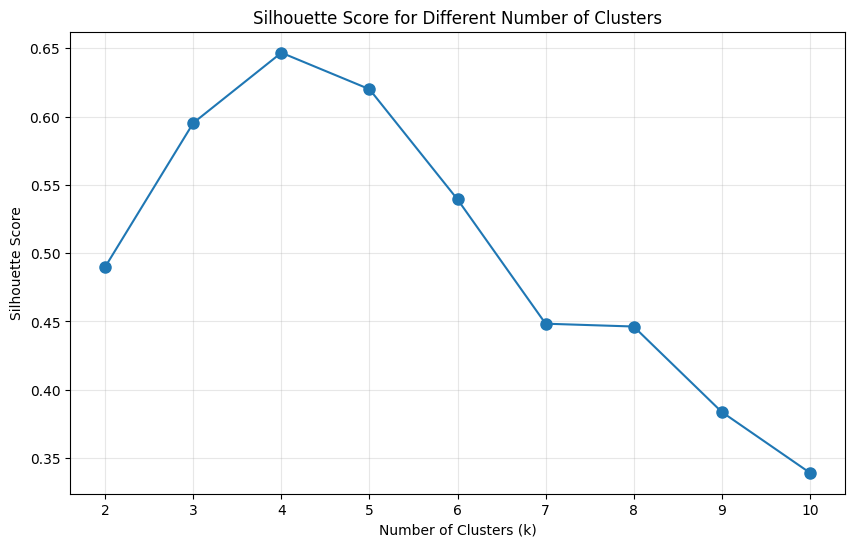

In [ ]:
#Plot the silhouette scores curve
plt.figure(figsize=(10,6))
plt.plot(k_range, silhouette_scores, 'o-', markersize = 8) #'0-': is the type of curve the graph is using; while markersize is size of the circle in this curve)
plt.title('Silhouette Score for Different Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha = 0.3)
plt.show()

In [ ]:
#BUILD THE FINAL KMEANS MODEL

final_kmeans = KMeans(n_clusters= 4, random_state =42, n_init = 10)

#fit the mode and get cluster labels
cluster_labels = final_kmeans.fit_predict(clustering_features)



Final model chosen by evaluating both the Silhouette Score and Inertia( within-cluster sum of squares)

In [ ]:
cluster_labels[:10]

array([0, 0, 0, 2, 3, 2, 2, 2, 1, 0], dtype=int32)

In [ ]:
#Add cluster labels to orginal dataframe
df_clustered = df.copy() #creates a copy of the original dataframe and stores it in a new dataframe claled df_clusteed. This is done to preserve the original data and avoid modifying
#it directly
df_clustered['predicted_cluster'] = cluster_labels #This line adds a new column called 'predicted_cluster' to df_clustered. And it holding the cluster_labels, the # of clusters the each
#row of data falls under


In [ ]:
df_clustered['predicted_cluster'].unique()

array([0, 2, 3, 1], dtype=int32)

In [ ]:
df_clustered.head()

,User ID,Instagram visit score,Spending_rank(0 to 100),predicted_cluster
0,0,63,24.050708,0
1,1,61,25.223290,0
2,2,104,18.528245,0
3,3,82,86.890232,2
4,4,14,31.492397,3


In [ ]:
#cluster distribution
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index() #we could have used Pd.Dataframe here, but we didnt use it, we used pd.Series instead because we wanted to add
#formula .value_counts() and . sort_index(). and Pd Dataframe wont allow us add fxn
print(cluster_counts)

0    1027
1     400
2     600
3     573
Name: count, dtype: int64


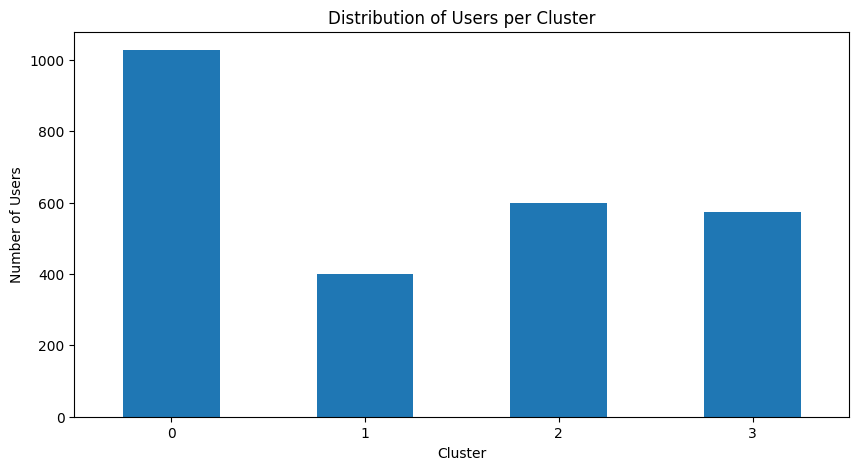

In [ ]:
plt.figure(figsize = (10,5))
cluster_counts.plot(kind = 'bar') #here we did a bar chart, so since we just want to count one category, we do cluster_counts. plot
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.title('Distribution of Users per Cluster')
plt.xticks(rotation = 0)
plt.show()

In [ ]:
cluster_characteristics = df_clustered.groupby('predicted_cluster')[['Instagram visit score', 'Spending_rank(0 to 100)']].mean() # grouped instgaram visit score, spending rank individually
#by predicted_cluster
display(cluster_characteristics)

,Instagram visit score,Spending_rank(0 to 100)
predicted_cluster,,
0,83.243427,19.872486
1,39.350000,65.132485
2,79.615000,85.024498
3,27.296684,24.309119


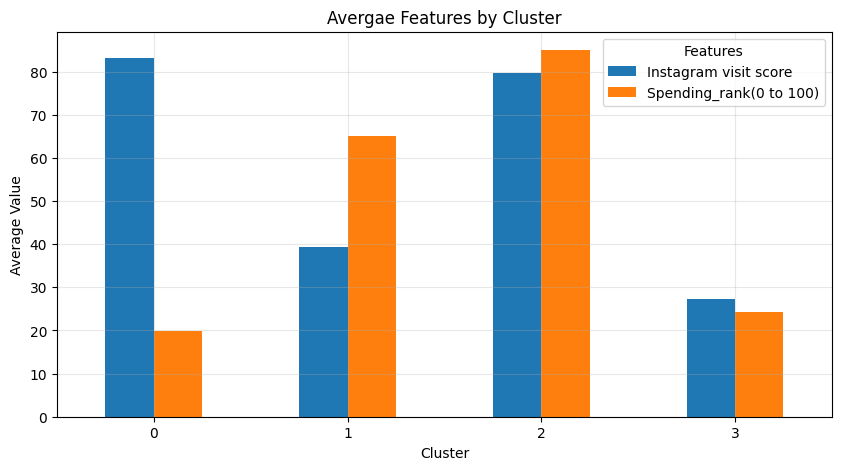

In [ ]:
#plot  4: Feature comparison by cluster
fig, axes = plt.subplots(figsize = (10,5)) #plt.subplots: to show difference between two variables, Plot multiple variable in a single graph side by side
cluster_characteristics.plot(kind = 'bar', ax = axes) # ax = axes to show a side by side to show difference between two variables, Plot multiple cariable in a single graph
axes.set_xlabel('Cluster')
axes.set_ylabel('Average Value')
axes.set_title('Avergae Features by Cluster')
axes.tick_params(axis ='x', rotation = 0) #_params
axes.legend(title = 'Features')
axes.grid(True, alpha = 0.3)
plt.show()